In [2]:
import pandas as pd
import joblib

# ==========================================
# 1. СОЗДАЕМ ЯДРО ЮРИДИЧЕСКОГО ИИ
# ==========================================
class LegalExpertEngine:
    def __init__(self):
        # Жесткие лимиты согласно архитектуре Приказа №108
        self.MIN_HEADS = 50          # Мин. порог для товарного стада
        self.MAX_NON_BREEDING = 300  # Лимит голов для беспородного скота
        self.AUDIT_THRESHOLD = 1000  # Порог для назначения ручного аудита

    def check_compliance(self, farmer_data):
        """
        Функция принимает строку данных (dict или pd.Series)
        и возвращает вердикт, штрафные баллы и список нарушений.
        """
        # Извлекаем признаки из нашего датасета
        declared_heads = int(farmer_data.get('amount_to_norm_ratio', 0))
        is_breeding = int(farmer_data.get('is_breeding', 0))
        is_selection = int(farmer_data.get('is_selection', 0))

        reasons = []
        status = "✅ Одобрено"
        penalty = 0  # Штраф к FutureScore

        # Правило 1: Логический конфликт селекции
        if is_selection == 1 and is_breeding == 0:
            status = "❌ Отказано"
            reasons.append("Нарушение: Запрос на селекционную субсидию без подтвержденного племенного статуса маточного поголовья.")
            penalty += 50

        # Правило 2: Минимальный порог
        if declared_heads < self.MIN_HEADS:
            status = "❌ Отказано"
            reasons.append(f"Нарушение: Заявленное поголовье ({declared_heads} гол.) ниже минимального порога рентабельности ({self.MIN_HEADS} гол.).")
            penalty += 40

        # Правило 3: Лимиты для беспородного скота
        if is_breeding == 0 and declared_heads > self.MAX_NON_BREEDING:
            status = "❌ Отказано"
            reasons.append(f"Критическое нарушение: Превышен лимит субсидирования товарного (беспородного) скота. Заявлено {declared_heads}, разрешено до {self.MAX_NON_BREEDING}.")
            penalty += 60

        # Правило 4: Аудит гигантов (если до этого не было отказов)
        if status != "❌ Отказано" and declared_heads >= self.AUDIT_THRESHOLD:
            status = "⚠️ Требуется аудит"
            reasons.append(f"Внимание (Пункт 14): Аномально крупная заявка ({declared_heads} гол.). Назначена выездная комиссия для пересчета.")
            penalty += 15 # Небольшой штраф за риск

        # Если нарушений нет
        if not reasons:
            reasons.append("Заявка полностью соответствует лимитам и требованиям Приказа МСХ РК.")

        return {
            "status": status,
            "penalty": penalty, # Эти баллы мы будем вычитать из FutureScore
            "details": reasons,
            "heads_calculated": declared_heads
        }

# ==========================================
# 2. ТЕСТИРОВАНИЕ НА НАШИХ ДАННЫХ
# ==========================================
print("🚀 Запуск тестирования Legal AI...\n")

# Имитируем 4 разные заявки из нашего final_dataset_pro.csv
test_data = [
    {"name": "Идеальный фермер", "amount_to_norm_ratio": 242.9, "is_breeding": 1, "is_selection": 1},
    {"name": "Мелкий двор", "amount_to_norm_ratio": 26.9, "is_breeding": 0, "is_selection": 0},
    {"name": "Фродер (наглеет)", "amount_to_norm_ratio": 850.5, "is_breeding": 0, "is_selection": 0},
    {"name": "Агро-Гигант", "amount_to_norm_ratio": 1200.0, "is_breeding": 1, "is_selection": 1},
    {"name": "Хитрец (селекция без породы)", "amount_to_norm_ratio": 150.0, "is_breeding": 0, "is_selection": 1}
]

expert = LegalExpertEngine()

for farmer in test_data:
    result = expert.check_compliance(farmer)
    print(f"👨‍🌾 {farmer['name']} (Поголовье: {int(farmer['amount_to_norm_ratio'])}, Плем: {farmer['is_breeding']}, Селекция: {farmer['is_selection']})")
    print(f"Вердикт: {result['status']}")
    print(f"Штраф к рейтингу: -{result['penalty']} баллов")
    for r in result['details']:
        print(f"  -> {r}")
    print("-" * 50)

# ==========================================
# 3. СОХРАНЕНИЕ МОДЕЛИ В .PKL
# ==========================================
filename = 'legal_engine.pkl'
joblib.dump(expert, filename)
print(f"\n✅ Модель успешно сохранена в файл: {filename}")
print("Теперь скачай этот файл слева в панели Colab (значок папки).")

🚀 Запуск тестирования Legal AI...

👨‍🌾 Идеальный фермер (Поголовье: 242, Плем: 1, Селекция: 1)
Вердикт: ✅ Одобрено
Штраф к рейтингу: -0 баллов
  -> Заявка полностью соответствует лимитам и требованиям Приказа МСХ РК.
--------------------------------------------------
👨‍🌾 Мелкий двор (Поголовье: 26, Плем: 0, Селекция: 0)
Вердикт: ❌ Отказано
Штраф к рейтингу: -40 баллов
  -> Нарушение: Заявленное поголовье (26 гол.) ниже минимального порога рентабельности (50 гол.).
--------------------------------------------------
👨‍🌾 Фродер (наглеет) (Поголовье: 850, Плем: 0, Селекция: 0)
Вердикт: ❌ Отказано
Штраф к рейтингу: -60 баллов
  -> Критическое нарушение: Превышен лимит субсидирования товарного (беспородного) скота. Заявлено 850, разрешено до 300.
--------------------------------------------------
👨‍🌾 Агро-Гигант (Поголовье: 1200, Плем: 1, Селекция: 1)
Вердикт: ⚠️ Требуется аудит
Штраф к рейтингу: -15 баллов
  -> Внимание (Пункт 14): Аномально крупная заявка (1200 гол.). Назначена выездная ко

✅ Файл cows.jpeg найден. Запускаем ИИ...


--- ТЕСТ: Проверка фермера ---
🔍 Сканирование фото: бараны.jpg
🐄 ИИ нашел на фото: 3 животных
📄 По документам заявлено: 2 голов
Вердикт системы: ✅ Подтверждено. Визуальный контроль пройден.


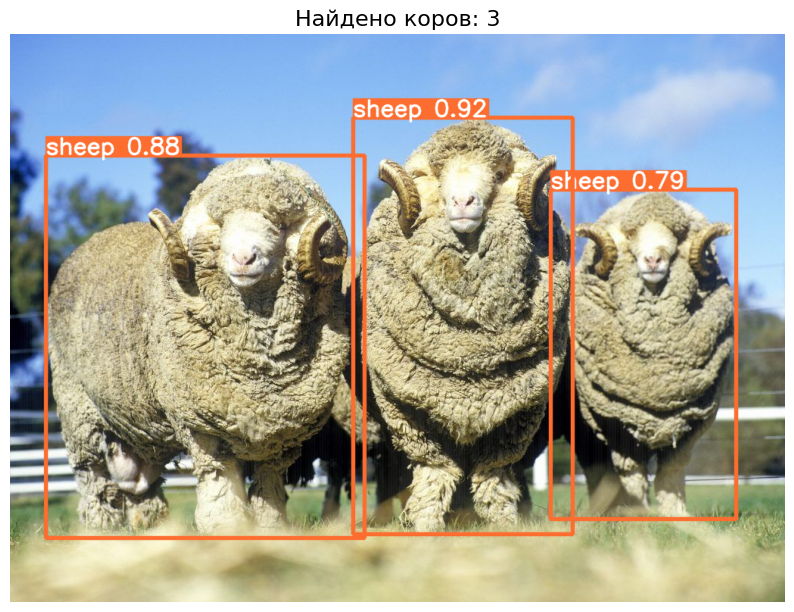

In [9]:
# 1. Установка библиотеки
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Проверяем, загрузил ли ты картинку
if not os.path.exists("cows1.jpg"):
    print("❌ ОШИБКА: Файл cows.jpeg не найден! Пожалуйста, загрузи его в левую панель Colab.")
else:
    print("✅ Файл cows.jpeg найден. Запускаем ИИ...\n")

    # ==========================================
    # 2. ЯДРО COMPUTER VISION
    # ==========================================
    class CVAuditor:
        def __init__(self):
            # Загружаем YOLOv8 Nano (самая быстрая для хакатонов)
            self.model = YOLO('yolov8n.pt')

            # В базе COCO: 17 = лошадь, 18 = овца, 19 = корова
            self.target_classes = [17, 18, 19]

        def analyze_photo(self, img_path, declared_count):
            print(f"🔍 Сканирование фото: {img_path}")

            # Запускаем распознавание
            results = self.model(img_path, verbose=False)
            detected_count = 0

            # Считаем только целевых животных
            for r in results:
                for box in r.boxes:
                    if int(box.cls[0]) in self.target_classes:
                        detected_count += 1

            print(f"🐄 ИИ нашел на фото: {detected_count} животных")
            print(f"📄 По документам заявлено: {declared_count} голов")

            # Логика Анти-Фрода
            ratio = detected_count / declared_count if declared_count > 0 else 0

            if ratio < 0.3:
                status = "🚨 ФРОД: Критическое расхождение."
            elif ratio < 0.8:
                status = "⚠️ Частичное расхождение. Возможен выпас."
            elif ratio > 1.5:
                status = "⚠️ Превышение. Скота больше, чем заявлено."
            else:
                status = "✅ Подтверждено. Визуальный контроль пройден."

            return detected_count, status, results[0]

    # ==========================================
    # 3. ТЕСТИРОВАНИЕ НА ТВОЕЙ КАРТИНКЕ
    # ==========================================
    auditor = CVAuditor()

    # Сценарий: Фермер честный, заявил 2 коровы
    print("\n--- ТЕСТ: Проверка фермера ---")
    detected, status, result_image = auditor.analyze_photo("бараны.jpg", declared_count=2)
    print(f"Вердикт системы: {status}")

    # ==========================================
    # 4. ВИЗУАЛИЗАЦИЯ (Показываем картинку)
    # ==========================================
    # Рисуем рамки, которые нашла нейросеть
    res_plot = result_image.plot()
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Найдено коров: {detected}", fontsize=16)
    plt.show()